# Q-Former Evaluation — MS COCO Checkpoint

Tests the trained `Blip2QFormerTrainer` checkpoint on four experiments:
1. **Image → Text Retrieval** — given an image, rank a set of captions by similarity
2. **Text → Image Retrieval** — given a caption, rank a set of images by similarity
3. **ITM Scoring** — binary match/no-match confidence for arbitrary (image, caption) pairs
4. **Embedding Visualisation** — t-SNE of image vs text embeddings to see alignment

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # project root

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from pathlib import Path
from transformers import ViTModel, ViTImageProcessor, AutoTokenizer, DistilBertModel

from networks.q_former import QFormer
from networks.blip2_trainer import Blip2QFormerTrainer

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


## 2. Load Model

In [2]:
CHECKPOINT = "../models_trained/trained_qformer_mscoco/best"

# ── ViT (frozen encoder) ─────────────────────────────────────────────────────
vit_processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
vit = ViTModel.from_pretrained("google/vit-base-patch16-224").to(device).eval()
for p in vit.parameters():
    p.requires_grad = False

# ── Q-Former + projection heads ───────────────────────────────────────────────
qformer = QFormer.from_pretrained(os.path.join(CHECKPOINT, "qformer"))
model = Blip2QFormerTrainer(qformer, embed_dim=256)
model.load_training_heads(CHECKPOINT)
model.to(device).eval()

# ── Tokenizer ─────────────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")

print("Model loaded.")
print(f"Temperature: {model.temp.item():.4f}")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded.
Temperature: 0.0879


## 3. Helper Functions

In [3]:
@torch.no_grad()
def encode_images(pil_images):
    """PIL list → normalised image embeddings [N, embed_dim]"""
    pixels = vit_processor(images=pil_images, return_tensors="pt").pixel_values.to(device)
    patch_embeds = vit(pixel_values=pixels).last_hidden_state          # [N, 197, 768]
    query_out, _ = model.qformer.encode_image(patch_embeds)            # [N, Q, 768]
    image_feats = F.normalize(model.vision_proj(query_out), dim=-1)    # [N, Q, 256]
    return image_feats  # per-query embeddings; caller can max-pool or mean-pool


@torch.no_grad()
def encode_texts(captions):
    """String list → normalised text embeddings [N, embed_dim]"""
    tok = tokenizer(captions, return_tensors="pt", padding=True,
                    truncation=True, max_length=512).to(device)
    text_out = model.qformer.encode_text(tok.input_ids, tok.attention_mask)  # [N, T, 768]
    text_feats = F.normalize(model.text_proj(text_out[:, 0, :]), dim=-1)     # [N, 256]
    return text_feats


@torch.no_grad()
def itm_score(pil_images, captions):
    """Score each (image, caption) pair. Returns match probability [N]."""
    assert len(pil_images) == len(captions)
    pixels = vit_processor(images=pil_images, return_tensors="pt").pixel_values.to(device)
    patch_embeds = vit(pixel_values=pixels).last_hidden_state
    tok = tokenizer(captions, return_tensors="pt", padding=True,
                    truncation=True, max_length=512).to(device)
    query_out, _ = model.qformer(
        visual_feats=patch_embeds,
        text_input_ids=tok.input_ids,
        text_attention_mask=tok.attention_mask,
        attention_mode="multi_modal",
        return_full_sequences=True,
    )  # [N, Q, 768]
    logits = model.itm_head(query_out).mean(dim=1)   # [N, 2]
    probs = logits.softmax(dim=-1)[:, 1]             # match probability
    return probs.cpu().numpy()


def load_sample_images(n=8, shard="00000"):
    """Load n images + captions from a COCO shard for quick experiments."""
    import pyarrow.parquet as pq
    pq_path = Path(f"../dataset/mscoco_images/{shard}.parquet")
    table = pq.read_table(pq_path, columns=["key", "caption", "status"])
    images, captions = [], []
    for key, cap, status in zip(table["key"].to_pylist(),
                                 table["caption"].to_pylist(),
                                 table["status"].to_pylist()):
        if status != "success" or not cap:
            continue
        jpg = Path(f"../dataset/mscoco_images/{shard}/{key}.jpg")
        if not jpg.exists():
            continue
        images.append(Image.open(jpg).convert("RGB").copy())
        captions.append(cap.strip())
        if len(images) == n:
            break
    return images, captions

print("Helpers ready.")

Helpers ready.


## 4. Experiment 1 — Image → Text Retrieval

Given an image, rank a pool of captions by similarity.

You have N image-caption pairs
One image is picked as the query
The query image is compared against all N captions (including its own) using the similarity score
Captions are ranked by that score — ideally the matching caption lands at rank 1

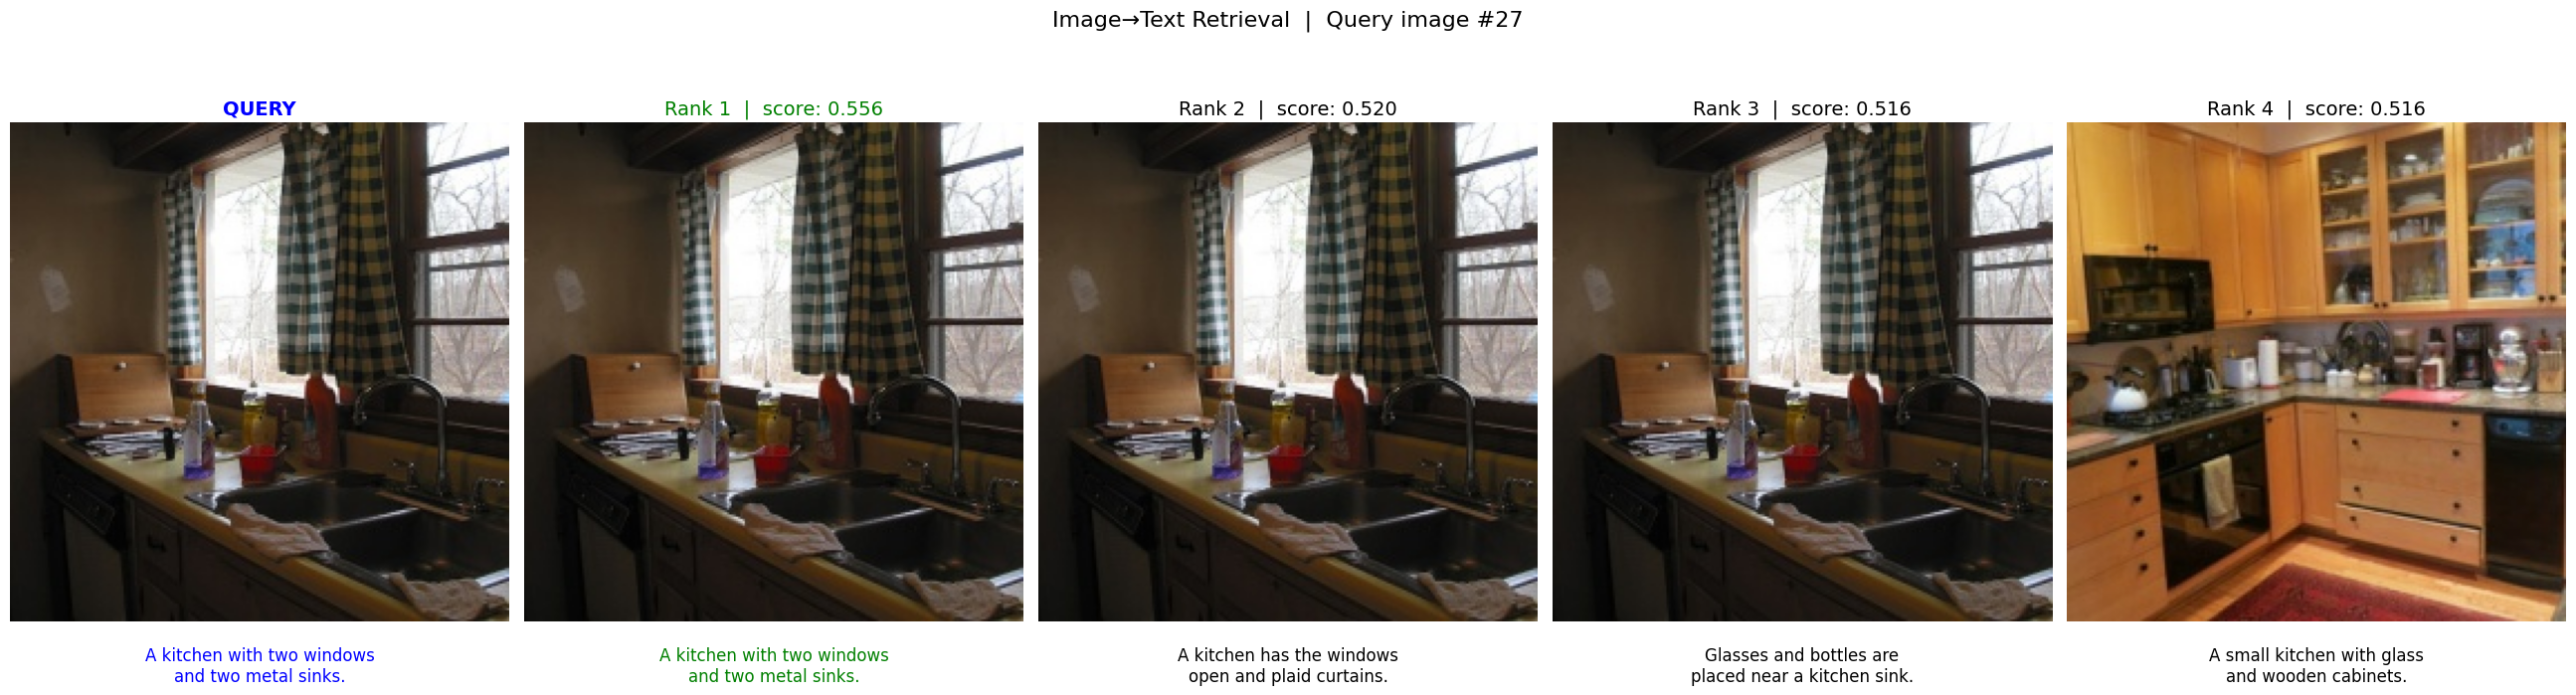


Ground-truth caption rank: 1 / 100


In [10]:
import textwrap

images, captions = load_sample_images(n=100)

image_feats = encode_images(images)
text_feats  = encode_texts(captions)

sim = torch.einsum("iqd,jd->iqj", image_feats, text_feats).max(dim=1).values

QUERY_IDX = np.random.randint(0, len(images))
scores = sim[QUERY_IDX].cpu().numpy()
ranked = np.argsort(scores)[::-1]

fig, axes = plt.subplots(1, 5, figsize=(26, 9))
fig.suptitle(f"Image→Text Retrieval  |  Query image #{QUERY_IDX}", fontsize=16, y=1.01)

# Query image
axes[0].imshow(images[QUERY_IDX])
axes[0].set_title("QUERY", color="blue", fontweight="bold", fontsize=14)
axes[0].text(0.5, -0.05,
             "\n".join(textwrap.wrap(captions[QUERY_IDX], width=28)),
             transform=axes[0].transAxes,
             fontsize=12, ha='center', va='top', color='blue')
axes[0].axis("off")

# Top-4 retrieved results
for rank, (ax, idx) in enumerate(zip(axes[1:], ranked[:4]), start=1):
    color = "green" if idx == QUERY_IDX else "black"
    ax.imshow(images[idx])
    ax.set_title(f"Rank {rank}  |  score: {scores[idx]:.3f}", color=color, fontsize=14)
    ax.text(0.5, -0.05,
            "\n".join(textwrap.wrap(captions[idx], width=28)),
            transform=ax.transAxes,
            fontsize=12, ha='center', va='top', color=color)
    ax.axis("off")

plt.tight_layout(rect=[0, 0.25, 1, 1])
plt.show()
print(f"\nGround-truth caption rank: {list(ranked).index(QUERY_IDX) + 1} / {len(captions)}")


## 5. Experiment 2 — Text → Image Retrieval

Given a caption, rank a pool of images.

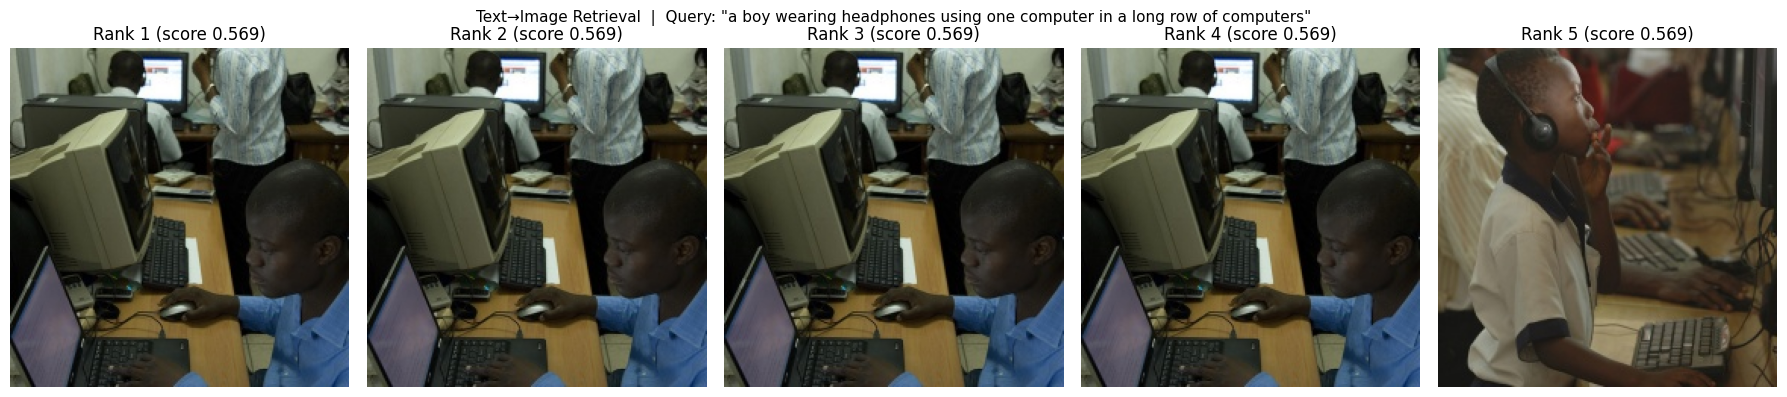


Ground-truth image rank: 10 / 100


In [11]:
QUERY_IDX = np.random.randint(0, len(captions))

# sim[i, j] = similarity(image_i, text_j)
# For text→image: look down column QUERY_IDX
scores = sim[:, QUERY_IDX].cpu().numpy()
ranked = np.argsort(scores)[::-1]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle(f'Text→Image Retrieval  |  Query: "{captions[QUERY_IDX][:80]}"', fontsize=11)

for rank, (ax, idx) in enumerate(zip(axes, ranked[:5]), start=1):
    color = "green" if idx == QUERY_IDX else "black"
    ax.imshow(images[idx])
    ax.set_title(f"Rank {rank} (score {scores[idx]:.3f})", color=color)
    ax.axis("off")

plt.tight_layout()
plt.show()
print(f"\nGround-truth image rank: {list(ranked).index(QUERY_IDX) + 1} / {len(images)}")

## 6. Experiment 3 — Recall@K (Quantitative)

Recall@K: what fraction of queries have their ground-truth match in the top-K results.
Run over a larger pool for a more meaningful number.

Experiment 3 gives you a quantitative score for the whole model, not just one sample.

It asks: "If I run retrieval on all N pairs, what fraction of queries find their correct match in the top K results?"

Recall@K means:

- R@1 — correct match is the #1 result. Strictest.
- R@5 — correct match is somewhere in the top 5
- R@10 — correct match is somewhere in the top 10

In [6]:
# Load a larger pool from multiple shards
all_images, all_captions = [], []
for shard in ["00000", "00001", "00002"]:
    imgs, caps = load_sample_images(n=50, shard=shard)
    all_images.extend(imgs)
    all_captions.extend(caps)

print(f"Pool size: {len(all_images)} pairs")

# Encode in small batches to avoid OOM
BATCH = 32
img_feats_all, txt_feats_all = [], []
for i in range(0, len(all_images), BATCH):
    img_feats_all.append(encode_images(all_images[i:i+BATCH]))
    txt_feats_all.append(encode_texts(all_captions[i:i+BATCH]))

img_feats_all = torch.cat(img_feats_all, dim=0)  # [N, Q, 256]
txt_feats_all = torch.cat(txt_feats_all, dim=0)  # [N, 256]

# Similarity matrix [N, N]
sim_full = torch.einsum("iqd,jd->iqj", img_feats_all, txt_feats_all).max(dim=1).values
N = sim_full.shape[0]

def recall_at_k(sim_matrix, k):
    """Fraction of queries where GT (diagonal) is in top-k."""
    topk = sim_matrix.topk(k, dim=1).indices  # [N, k]
    gt   = torch.arange(N, device=topk.device).unsqueeze(1)  # [N, 1]
    return (topk == gt).any(dim=1).float().mean().item()

print("Image → Text retrieval:")
for k in [1, 5, 10]:
    print(f"  R@{k}: {recall_at_k(sim_full, k)*100:.1f}%")

print("\nText → Image retrieval:")
for k in [1, 5, 10]:
    print(f"  R@{k}: {recall_at_k(sim_full.T, k)*100:.1f}%")

Pool size: 150 pairs
Image → Text retrieval:
  R@1: 28.7%
  R@5: 89.3%
  R@10: 98.7%

Text → Image retrieval:
  R@1: 29.3%
  R@5: 88.7%
  R@10: 97.3%


## 7. Experiment 4 — ITM Scoring

Score matched vs mismatched pairs using the ITM head.

Experiment 4 tests the ITM head — a binary classifier that answers: "Does this image and caption match or not?"

What it does:

It takes 6 image-caption pairs and scores them twice:

- Matched pairs — the correct image paired with its own caption
- Mismatched pairs — the same images paired with a shifted caption (image 0 gets caption 1, image 1 gets caption 2, etc.)

The ITM head outputs a probability between 0 and 1:

- Close to 1.0 → model thinks it's a match
- Close to 0.5 → model is uncertain
- Close to 0.0 → model thinks it's not a match

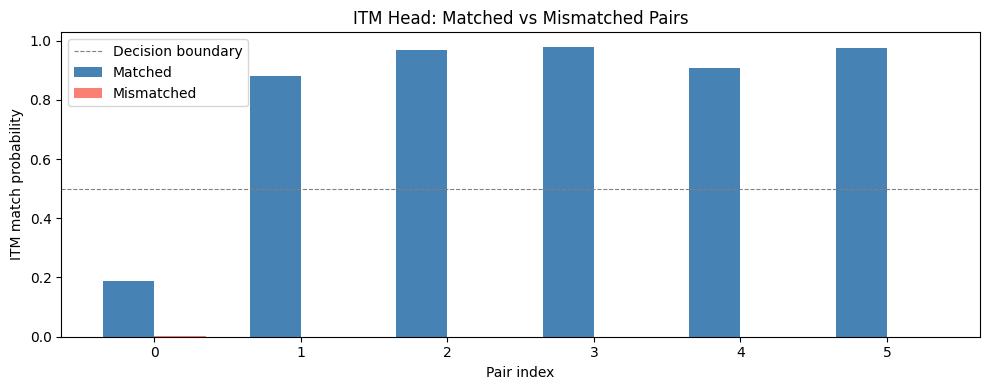

Mean matched score:    0.816
Mean mismatched score: 0.000


In [7]:
images_itm, captions_itm = load_sample_images(n=6)

# Matched pairs (ground truth)
matched_scores   = itm_score(images_itm, captions_itm)
# Mismatched: shift captions by 1
shuffled_caps    = captions_itm[1:] + [captions_itm[0]]
mismatched_scores = itm_score(images_itm, shuffled_caps)

x = np.arange(len(images_itm))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width/2, matched_scores,   width, label="Matched",   color="steelblue")
ax.bar(x + width/2, mismatched_scores, width, label="Mismatched", color="salmon")
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, label="Decision boundary")
ax.set_xlabel("Pair index")
ax.set_ylabel("ITM match probability")
ax.set_title("ITM Head: Matched vs Mismatched Pairs")
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean matched score:    {matched_scores.mean():.3f}")
print(f"Mean mismatched score: {mismatched_scores.mean():.3f}")

## 8. Experiment 5 — Embedding Visualisation (t-SNE)

Plot image and text embeddings together. Paired points should cluster nearby if alignment is good.

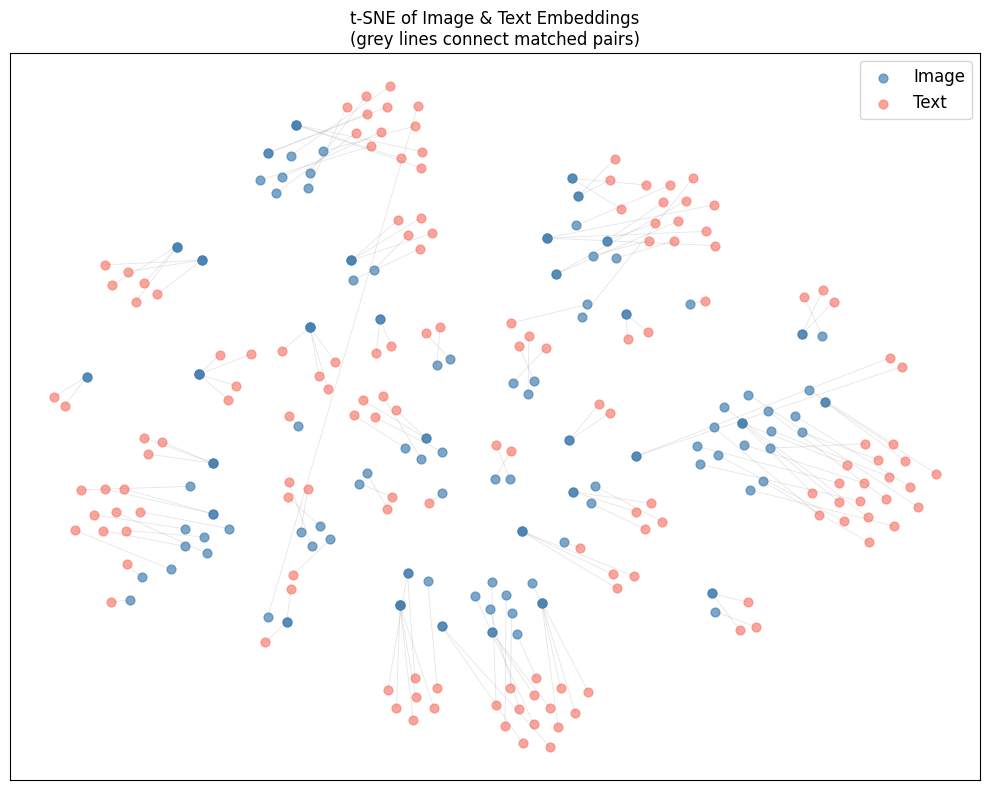

In [8]:
from sklearn.manifold import TSNE

# Use the pool encoded in Experiment 3
# Mean-pool over query dimension for image embeddings
img_vecs = img_feats_all.mean(dim=1).cpu().numpy()  # [N, 256]
txt_vecs = txt_feats_all.cpu().numpy()               # [N, 256]

combined = np.concatenate([img_vecs, txt_vecs], axis=0)  # [2N, 256]
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
embedded = tsne.fit_transform(combined)

img_2d = embedded[:N]
txt_2d = embedded[N:]

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(img_2d[:, 0], img_2d[:, 1], s=40, alpha=0.7, color="steelblue", label="Image")
ax.scatter(txt_2d[:, 0], txt_2d[:, 1], s=40, alpha=0.7, color="salmon",    label="Text")

# Draw lines connecting matched pairs
for i in range(N):
    ax.plot([img_2d[i, 0], txt_2d[i, 0]],
            [img_2d[i, 1], txt_2d[i, 1]],
            color="grey", alpha=0.2, linewidth=0.6)

ax.legend(fontsize=12)
ax.set_title("t-SNE of Image & Text Embeddings\n(grey lines connect matched pairs)")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

## 9. Quick Sanity Check — Custom Caption

Pick any image and score it against a list of captions you write yourself.

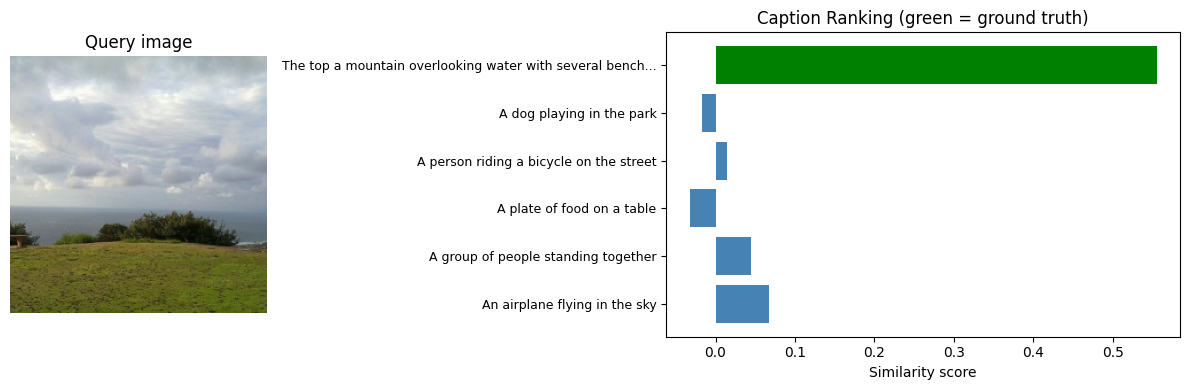

Ground truth rank: 1 / 6


In [9]:
images_s, captions_s = load_sample_images(n=2, shard="00001")
query_image = images_s[1]

candidate_captions = [
    captions_s[1],                          # ground truth
    "A dog playing in the park",
    "A person riding a bicycle on the street",
    "A plate of food on a table",
    "A group of people standing together",
    "An airplane flying in the sky",
]

img_feat = encode_images([query_image])  # [1, Q, 256]
txt_feat = encode_texts(candidate_captions)  # [C, 256]

scores = torch.einsum("qd,cd->qc", img_feat[0], txt_feat).max(dim=0).values
scores = scores.cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1, 2]})
axes[0].imshow(query_image)
axes[0].set_title("Query image")
axes[0].axis("off")

colors = ["green" if i == 0 else "steelblue" for i in range(len(candidate_captions))]
bars = axes[1].barh(range(len(candidate_captions)), scores, color=colors)
axes[1].set_yticks(range(len(candidate_captions)))
axes[1].set_yticklabels([f"{c[:55]}..." if len(c) > 55 else c
                         for c in candidate_captions], fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel("Similarity score")
axes[1].set_title("Caption Ranking (green = ground truth)")
plt.tight_layout()
plt.show()

gt_rank = int(np.argsort(scores)[::-1].tolist().index(0)) + 1
print(f"Ground truth rank: {gt_rank} / {len(candidate_captions)}")